This notebook demonstrates the use of the `analyse_moves` function which gives an overview of the scoring consequences of all moves from a given position

Specifically, it gives an output that shows for each move from a given position:
- what the relative score (with optimal) play following that move is compared to the optimal score
- what the impact to each player's score is, ie: does it add more points to your hand or take away points from the opponent

This is intended to help develop an understanding of what good strategy looks like, whether to focus on offensive or defensive play

In [1]:
from cardgame import Game, analyse_moves

In [15]:
# find a position with 10 cards remaining where 4 of them are facedown
target_cards_remaining = 11
target_fd_cards_remaining = 4

while True:
    game = Game.deal()
    while game.legal_moves:
        game = game.random_move()
    moves_to_undo = max(0, len(game.moves) - 36 + target_cards_remaining)
    if not moves_to_undo:
        continue
    if len(game.undo(moves_to_undo).board.facedown_cards) == target_fd_cards_remaining:
        break
evaluation_state = game.undo(moves_to_undo)
evaluation_state

In [16]:
def display_analysis(game, game_analysis):
    ordered_moves = sorted(
        game_analysis.items(), key=lambda k: k[1]["combined"], reverse=True
    )
    (row, col), best_move = ordered_moves[0]
    print(f"The best move is to take the {best_move['card']} at R{row}C{col}")
    print(
        f"The player to move (P{'2' if len(game.moves) % 2 else '1'}) scores an average of {best_move['player_mean']:.2f}"
    )
    print(f"The opponent scores an average of {best_move['opponent_mean']:.2f}")
    for (row, col), move_details in ordered_moves[1:]:
        print()
        print(
            f"Taking the {move_details['card']} at R{row}C{col} is worse than the best move by an average of {move_details['combined']:.2f}"
        )
        print(
            f"The player to move scores {move_details['defensive']:.2f} points {'more' if move_details['defensive'] > 0 else 'less'}"
        )
        print(
            f"The opponent scores {move_details['offensive']:.2f} points {'more' if move_details['offensive'] > 0 else 'less'}"
        )

In [22]:
analysis = analyse_moves(evaluation_state)
display_analysis(evaluation_state, analysis)

The best move is to take the 4♣ at R3C0
The player to move (P2) scores an average of 24.20
The opponent scores an average of 18.73

Taking the ?? at R3C2 is worse than the best move by an average of -1.44
The player to move scores -3.30 points less
The opponent scores -1.86 points less

Taking the ?? at R3C3 is worse than the best move by an average of -1.47
The player to move scores 0.56 points more
The opponent scores 2.03 points more

Taking the ?? at R0C5 is worse than the best move by an average of -1.53
The player to move scores 0.32 points more
The opponent scores 1.85 points more

Taking the 7♦ at R3C4 is worse than the best move by an average of -1.77
The player to move scores -2.26 points less
The opponent scores -0.48 points less


In [18]:
evaluation_state.evaluate()

{'Evaluation': ProbEval(24/24 possibilities, {4: 10, 6: 9, 7: 5}),
 'Deterministic optimal moves': (6♠, (4, 4)),
 'Known info for other branches': {(5,
   3): ProbEval(24/24 possibilities, {4: 24}),
  (0, 4): ProbEval(24/24 possibilities, {3: 6, 4: 12, 6: 6}),
  (4, 3): ProbEval(24/24 possibilities, {4: 10, 6: 9, 7: 5}),
  (0, 5): {2♠: ProbEval(6/6 possibilities, {3: 1, 4: 3, 8: 1, 9: 1}),
   4♦: ProbEval(6/6 possibilities, {4: 2, 5: 2, 9: 2}),
   A♣: ProbEval(6/6 possibilities, {3: 2, 4: 3, 5: 1}),
   K♣: ProbEval(6/6 possibilities, {4: 2, 5: 2, 9: 2})}}}

A move's offensive and defensive character is the asymmetry in how it impacts your score and your opponents score
- A move that reduces your opponents score is more offensive
- A move that increases your own score is more defensive

The only reference point we have here is taking the change in outcomes by making a certain move as compared to the best move in a given position, so everything is measured from that

We then have our 2 points, the change in your score vs. the best move and the change in your opponents score vs. the best move

Using these we can categorise the moves available as being more offensive/defensive in character

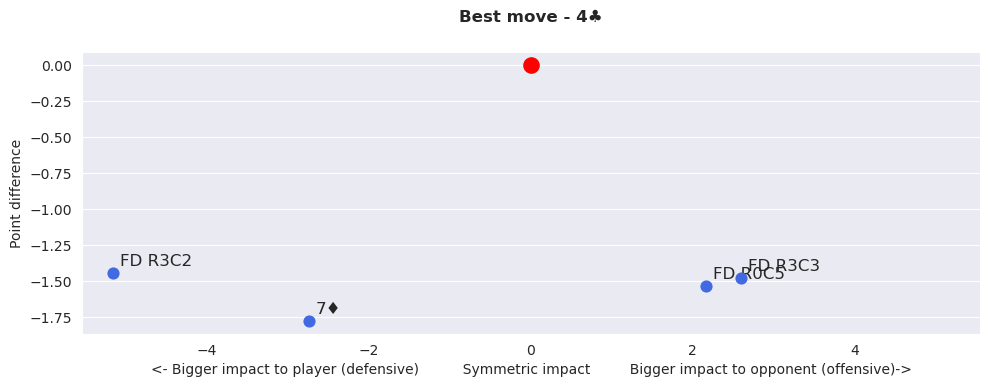

In [24]:
import matplotlib.pylab as plt
import seaborn as sns
from operator import itemgetter

sns.set_style("darkgrid")

fig, ax = plt.subplots(figsize=(10, 4))

best_move = max(analysis.values(), key=itemgetter("combined"))

for marker, data in analysis.items():
    off = data["offensive"]
    defv = data["defensive"]
    comb = data["combined"]
    x = off + defv
    y = comb
    is_best = comb == best_move["combined"]  # or abs(comb) < 0.01
    color = "red" if is_best else "royalblue"
    size = 120 if is_best else 60
    ax.scatter(x, y, c=color, s=size, zorder=5)
    if not is_best:
        card_str = str(data["card"])
        if card_str == "??":
            card_str = f"FD R{marker[0]}C{marker[1]}"
        ax.annotate(
            card_str, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=12
        )

ax.text(
    0,
    0.3,
    f"Best move - {str(best_move['card'])}",
    ha="center",
    fontsize=12,
    fontweight="bold",
)
ax.set_ylabel("Evaluation difference")
ax.set_xlabel(
    "<- Bigger impact to player (defensive)          Symmetric impact         Bigger impact to opponent (offensive)->"
)
curr = max(abs(bound) for bound in ax.get_xlim())
ax.set_xlim(-curr, curr)
plt.grid(axis="x")
plt.tight_layout()
plt.show()